Summary: Here we invert DC resistivity data for a single Wenner sounding. We demonstrate 3 approaches that can be used to invert 1D data in SimPEG:

A weighted least-squares inversion where the number of layers and their thicknesses are fixed.

An iteratively reweighted least-squares (IRLS) inversion to recover sparse and/or blocky structures.

A parametric inversion where we invert for the layer thicknesses and electrical properties assuming a 3-layered Earth.

The weighted least-squares approach is a great introduction to geophysical inversion with SimPEG. One drawback however, is that it recovers smooth structures which may not be representative of the true model. To recover sparse and/or blocky 1D structures, we demonstrate an iteratively reweighted least-squares approach. If the number of layers is known, but their depths, thicknesses and conductivities are not, we can use a parametric inversion approach.

In [18]:
# SimPEG functionality
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.utils import plot_1d_layer_model, download
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)

# discretize functionality
from discretize import TensorMesh

# Basic Python functionality
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tarfile

mpl.rcParams.update({"font.size": 14})

In [19]:
# URL to download from repository assets
data_source = "https://github.com/simpeg/user-tutorials/raw/main/assets/05-dcr/inv_dcr_1d_files.tar.gz"

# download the data
downloaded_data = download(data_source, overwrite=True)

# unzip the tarfile
tar = tarfile.open(downloaded_data, "r")
tar.extractall()
tar.close()

# path to the directory containing our data
dir_path = downloaded_data.split(".")[0] + os.path.sep

# files to work with
data_filename = dir_path + "app_res_1d_data.dobs"

overwriting c:\Users\maxim\Projects\Simpeg-inversion-practice\inv_dcr_1d_files.tar.gz
   saved to: c:\Users\maxim\Projects\Simpeg-inversion-practice\inv_dcr_1d_files.tar.gz
Download completed!


C:\Users\maxim\AppData\Local\Temp\ipykernel_134468\329559176.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [20]:
# Load data
dobs = np.loadtxt(str(data_filename))
print("Data shape: ", dobs.shape)

Data shape:  (25, 13)


In [21]:
# Extract A, B, M and N electrode locations and the observed data
A_electrodes = dobs[:, 0:3]
B_electrodes = dobs[:, 3:6]
M_electrodes = dobs[:, 6:9]
N_electrodes = dobs[:, 9:12]
dobs = dobs[:, -1]
print(dobs)

[ 982.31 1023.5  1094.3  1138.1  1133.5  1273.9  1296.3  1403.8  1371.2
 1404.6  1352.8  1441.1  1420.6  1262.6  1345.7  1273.6  1247.1  1180.3
 1138.9  1110.1  1056.9  1009.4   987.02  927.96  894.71]


In [22]:
# Compute the AB/2 separation for the 1D Wenner array
AB_separations = np.sqrt(np.sum((A_electrodes - B_electrodes) ** 2, axis=1))

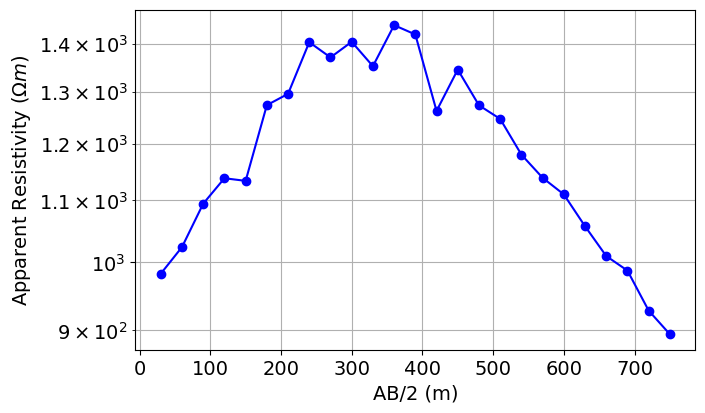

In [23]:
# Plot apparent resistivity as a function of AB/2
fig = plt.figure(figsize=(8, 4))
mpl.rcParams.update({"font.size": 14})
ax1 = fig.add_axes([0.15, 0.1, 0.7, 0.85])
ax1.semilogy(AB_separations / 2, dobs, "b-o")
ax1.grid(which="both")
ax1.set_xlabel("AB/2 (m)")
ax1.set_ylabel(r"Apparent Resistivity ($\Omega m$)")
plt.show()